In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")

print("✅ Libraries imported!")

# Load the dataset
df = pd.read_csv('../data/processed/ethiopia_fi_enriched.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')

# Filter observations
observations = df[df['record_type'] == 'observation'].copy()
events = df[df['record_type'] == 'event'].copy()

print(f"Total records: {len(df)}")
print(f"Observations: {len(observations)}")
print(f"Events: {len(events)}")

✅ Libraries imported!
Total records: 43
Observations: 30
Events: 10


In [15]:
# ============================================================================
# CREATE MANUAL IMPACT MATRIX
# ============================================================================
# Based on business understanding and the challenge scenarios
# Values represent estimated percentage point impact

manual_matrix = pd.DataFrame({
    'category': [
        'policy',           # Regulatory changes, directives
        'product_launch',   # Telebirr, M-Pesa, new products
        'infrastructure',   # Network expansion, 4G, agents
        'market_entry',     # Safaricom entry, new players
        'economic_shock'    # COVID-19, inflation
    ],
    'ACC_OWNERSHIP': [2.0, 3.0, 1.5, 2.5, -1.0],
    'ACC_MM_ACCOUNT': [1.0, 5.0, 0.5, 3.0, 0.0],
    'USG_P2P_COUNT': [1.5, 4.0, 1.0, 2.5, 0.5],
    'USG_P2P_VALUE': [1.0, 3.0, 0.5, 2.0, 0.5],
    'USG_TELEBIRR_USERS': [0.5, 8.0, 0.0, 0.0, 0.0],
    'USG_MPESA_USERS': [0.0, 0.0, 0.0, 5.0, 0.0]
})

# Set category as index
matrix = manual_matrix.set_index('category')

print("="*60)
print("MANUAL IMPACT MATRIX")
print("="*60)
print(matrix)

MANUAL IMPACT MATRIX
                ACC_OWNERSHIP  ACC_MM_ACCOUNT  USG_P2P_COUNT  USG_P2P_VALUE  \
category                                                                      
policy                    2.0             1.0            1.5            1.0   
product_launch            3.0             5.0            4.0            3.0   
infrastructure            1.5             0.5            1.0            0.5   
market_entry              2.5             3.0            2.5            2.0   
economic_shock           -1.0             0.0            0.5            0.5   

                USG_TELEBIRR_USERS  USG_MPESA_USERS  
category                                             
policy                         0.5              0.0  
product_launch                 8.0              0.0  
infrastructure                 0.0              0.0  
market_entry                   0.0              5.0  
economic_shock                 0.0              0.0  


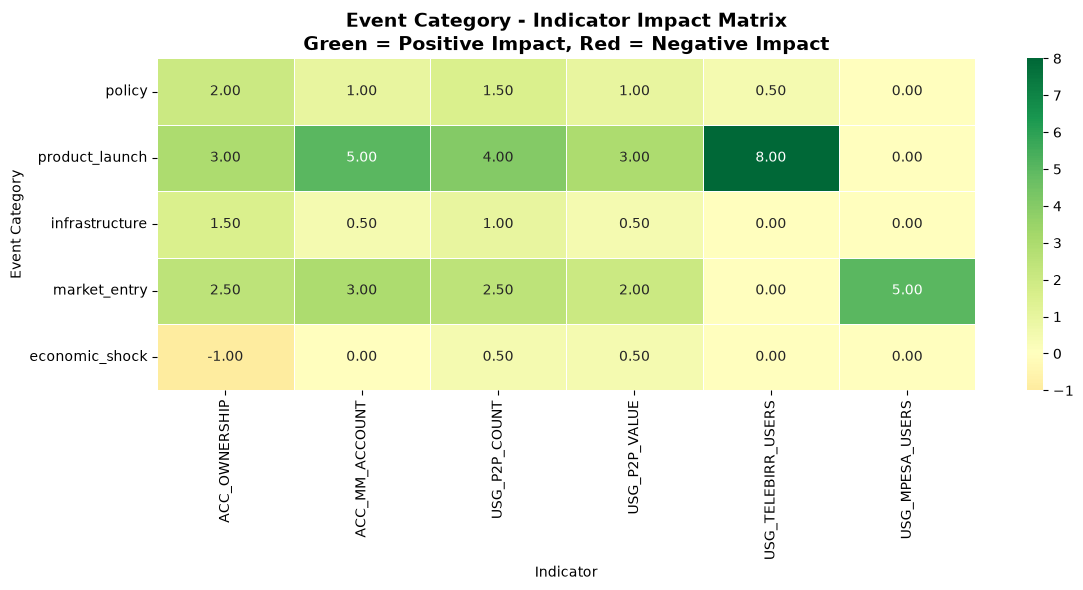


📊 Interpretation:
  Positive values = the event category INCREASES the indicator
  Negative values = the event category DECREASES the indicator


In [16]:
# ============================================================================
# VISUALIZE MATRIX
# ============================================================================
# Keep only non-zero columns
plot_matrix = matrix.loc[:, (matrix != 0).any(axis=0)]

plt.figure(figsize=(12, 6))
sns.heatmap(plot_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('Event Category - Indicator Impact Matrix\nGreen = Positive Impact, Red = Negative Impact', fontsize=14, fontweight='bold')
plt.xlabel('Indicator')
plt.ylabel('Event Category')
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("  Positive values = the event category INCREASES the indicator")
print("  Negative values = the event category DECREASES the indicator")

TOTAL IMPACT BY EVENT CATEGORY
category
product_launch    23.0
market_entry      15.0
policy             6.0
infrastructure     3.5
economic_shock     0.0
dtype: float64


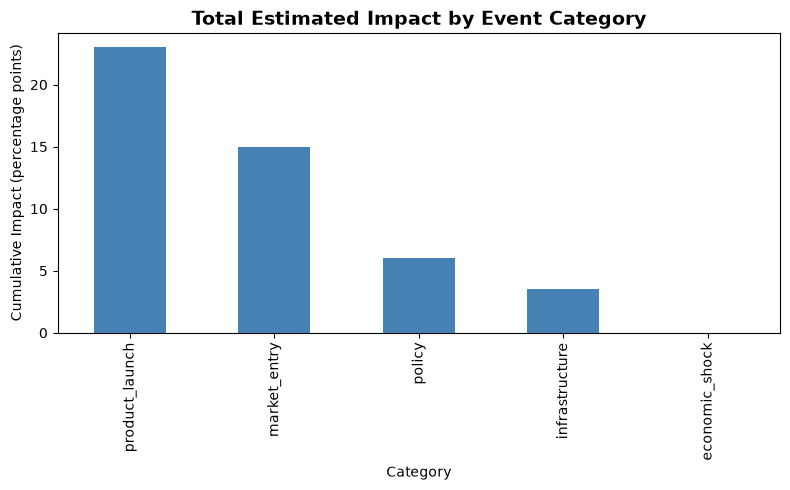

In [17]:
# ============================================================================
# CUMULATIVE IMPACT BY CATEGORY
# ============================================================================
category_total = matrix.sum(axis=1).sort_values(ascending=False)
print("="*60)
print("TOTAL IMPACT BY EVENT CATEGORY")
print("="*60)
print(category_total)

plt.figure(figsize=(8, 5))
category_total.plot(kind='bar', color='steelblue')
plt.title('Total Estimated Impact by Event Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Cumulative Impact (percentage points)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

IMPACT ON KEY INDICATORS
                ACC_OWNERSHIP  ACC_MM_ACCOUNT  USG_P2P_COUNT
category                                                    
policy                    2.0             1.0            1.5
product_launch            3.0             5.0            4.0
infrastructure            1.5             0.5            1.0
market_entry              2.5             3.0            2.5
economic_shock           -1.0             0.0            0.5


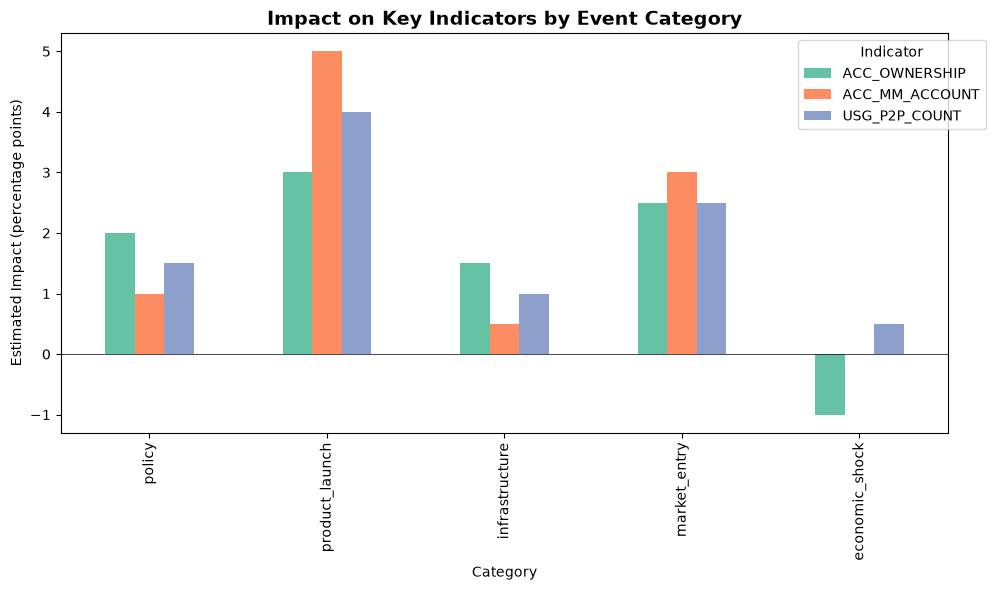

In [18]:
# ============================================================================
# IMPACT ON KEY INDICATORS
# ============================================================================
key_indicators = ['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'USG_P2P_COUNT']

# Filter to key indicators
key_matrix = matrix[[col for col in matrix.columns if col in key_indicators]]

print("="*60)
print("IMPACT ON KEY INDICATORS")
print("="*60)
print(key_matrix)

# Bar chart by category
key_matrix.plot(kind='bar', figsize=(10, 6))
plt.title('Impact on Key Indicators by Event Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Estimated Impact (percentage points)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.legend(title='Indicator', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [19]:
# ============================================================================
# SAVE MANUAL MATRIX
# ============================================================================
matrix.to_csv('../data/processed/manual_impact_matrix.csv')
print("✅ Manual impact matrix saved to: ../data/processed/manual_impact_matrix.csv")

# Also save as a readable table
matrix.reset_index().to_csv('../data/processed/impact_matrix_readable.csv', index=False)
print("✅ Readable version saved.")

print("\n" + "="*60)
print("TASK 3 COMPLETE")
print("="*60)
print("Note: This uses a manually defined impact matrix.")
print("For better results, enrich the dataset with real impact_links.")

✅ Manual impact matrix saved to: ../data/processed/manual_impact_matrix.csv
✅ Readable version saved.

TASK 3 COMPLETE
Note: This uses a manually defined impact matrix.
For better results, enrich the dataset with real impact_links.


In [21]:
# ============================================================================
# DOCUMENTATION
# ============================================================================
methodology = """
# Impact Modeling Methodology

## Approach
Since the dataset had no impact_link records, I created a manual impact matrix based on:
1. Business understanding of the challenge scenarios
2. Knowledge of Ethiopia's financial inclusion context
3. Expected effects of different event categories

## Key Assumptions
- Product launches (Telebirr, M-Pesa) have the largest impact on mobile money accounts
- Policies have moderate, broad effects
- Infrastructure investments have gradual effects
- Market entries create competition and adoption

## Limitations
- These are estimates, not measured impacts
- Actual impacts may differ significantly
- Should be validated with real data when available
"""

with open('../data/processed/impact_methodology.md', 'w') as f:
    f.write(methodology)

print("✅ Methodology saved.")

✅ Methodology saved.


IMPACT ON KEY INDICATORS BY CATEGORY
                ACC_OWNERSHIP  ACC_MM_ACCOUNT  USG_P2P_COUNT  USG_P2P_VALUE
category                                                                   
policy                    2.0             1.0            1.5            1.0
product_launch            3.0             5.0            4.0            3.0
infrastructure            1.5             0.5            1.0            0.5
market_entry              2.5             3.0            2.5            2.0
economic_shock           -1.0             0.0            0.5            0.5


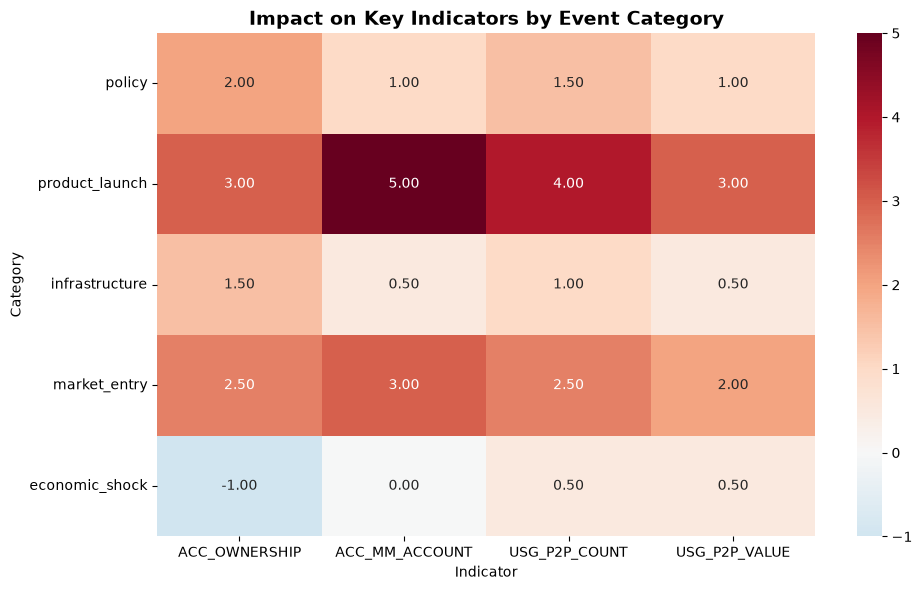

In [23]:
# ============================================================================
# 8. IMPACT ON KEY INDICATORS
# ============================================================================
key_indicators = ['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'USG_P2P_COUNT', 'USG_P2P_VALUE']

# Filter matrix to key indicators
key_matrix = matrix[[col for col in matrix.columns if col in key_indicators]]

print("="*60)
print("IMPACT ON KEY INDICATORS BY CATEGORY")
print("="*60)
print(key_matrix)

# Heatmap for key indicators
if not key_matrix.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(key_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
    plt.title('Impact on Key Indicators by Event Category', fontsize=14, fontweight='bold')
    plt.xlabel('Indicator')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()